In [ ]:
import jax
import jax.numpy as jnp
from jax.scipy.special import gammaln

jax.config.update("jax_enable_x64", True)  # recommended for Laplace work

Array = jnp.ndarray

# ---------------------------------------------------------------------
# Forward Laplace transform
# ---------------------------------------------------------------------

def forward_laplace_from_samples(t: Array, f: Array, s: Array) -> Array:
    """
    Numerically approximate F(s) = ∫_0^∞ f(t) e^{-s t} dt from samples {t_i, f_i}.
    Uses a composite trapezoid on [0, t_max]. Choose t_max so f(t)≈0 past it.

    Args:
      t: shape (N,), nondecreasing grid starting at 0.
      f: shape (N,), samples f(t_i).
      s: shape (M,), complex or real s values with Re(s) >= 0 typically.

    Returns:
      F: shape (M,), complex128
    """
    t = jnp.asarray(t, dtype=jnp.float64)
    f = jnp.asarray(f, dtype=jnp.complex128)
    s = jnp.asarray(s, dtype=jnp.complex128)

    # trapezoid weights for a possibly nonuniform grid
    dt = jnp.diff(t)
    w = jnp.concat([dt[:1] / 2.0, (dt[:-1] + dt[1:]) / 2.0, dt[-1:] / 2.0])

    # broadcast: (N,) -> (M,N) via exp(-s[:,None]*t[None,:])
    kernel = jnp.exp(-s[:, None] * t[None, :])
    F = jnp.sum(kernel * (w * f)[None, :], axis=1)
    return F.astype(jnp.complex128)


def forward_laplace_change_of_vars(
    f_fn, s: Array, L: float = 1.0, N: int = 800, eps: float = 1e-10
) -> Array:
    """
    Forward Laplace via change of vars t = L x/(1-x), x ∈ [0,1), so [0,∞) is covered.

    F(s) = ∫_0^1 f(L x/(1-x)) e^{-s L x/(1-x)} * (L/(1-x)^2) dx  (trapezoid in x)

    Args:
      f_fn: callable mapping Array[t] -> Array[f(t)], JAX-friendly (vectorized/broadcastable).
      s: shape (M,), complex or real s values.
      L: time-scale parameter; pick on the order of the decay scale of f(t).
      N: number of x-panels (N+1 points). Increase for tighter tolerance.
      eps: avoid x=1 exactly to prevent overflow.

    Returns:
      F: shape (M,), complex128
    """
    s = jnp.asarray(s, dtype=jnp.complex128)
    x = jnp.linspace(0.0, 1.0 - eps, N + 1, dtype=jnp.float64)
    dx = x[1] - x[0]

    t = L * x / (1.0 - x)
    jac = L / (1.0 - x) ** 2

    fx = jnp.asarray(f_fn(t), dtype=jnp.complex128)

    # trapezoid weights on x
    w = jnp.ones_like(x) * dx
    w = w.at[0].set(dx / 2.0)
    w = w.at[-1].set(dx / 2.0)

    kernel = jnp.exp(-s[:, None] * t[None, :])
    F = jnp.sum(kernel * (w * jac * fx)[None, :], axis=1)
    return F.astype(jnp.complex128)

# ---------------------------------------------------------------------
# Inverse Laplace transform: Durbin / Fourier–Bromwich
# ---------------------------------------------------------------------

def inverse_laplace_durbin(
    F_fn, t: Array, gamma: float | None = None, n_freq: int = 512
) -> Array:
    """
    Invert via the Fourier/Bromwich form:
      f(t) = e^{gamma t}/π ∫_0^∞ Re[ F(gamma + iω) e^{i ω t} ] dω,
    approximated by a trapezoid rule on ω.

    Args:
      F_fn: callable mapping Array[s] (complex) -> Array[F(s)] (complex). Must broadcast.
      t: times to evaluate, shape (T,), t>0.
      gamma: real shift > abscissa of convergence (right of all singularities).
              If None, a mild default gamma = 0.5 / max(t) is used (adjust if needed).
      n_freq: number of frequency panels (n_freq+1 samples up to Ω_max).

    Heuristics:
      Let t_max = max(t). We set h = π / t_max (Nyquist-ish), Ω_max = n_freq * h.

    Returns:
      f: shape (T,), real-valued (imag residuals discarded).
    """
    t = jnp.atleast_1d(jnp.asarray(t, dtype=jnp.float64))
    tmax = jnp.max(t)
    gamma = jnp.asarray(0.5 / (tmax + 1e-15) if gamma is None else gamma, dtype=jnp.float64)

    h = jnp.pi / (tmax + 1e-15)  # frequency step
    omega = jnp.arange(n_freq + 1, dtype=jnp.float64) * h  # [0, Ω_max]

    # Trapezoid weights in ω
    w = jnp.ones_like(omega)
    w = w.at[0].set(0.5)

    s = gamma + 1j * omega
    Fw = jnp.asarray(F_fn(s), dtype=jnp.complex128)  # shape (K,)

    # matrix of e^{i ω_k t_j}
    E = jnp.exp(1j * omega[:, None] * t[None, :])
    integrand = jnp.real((Fw[:, None] * E) * w[:, None])  # (K,T)

    f = jnp.exp(gamma * t) * (h / jnp.pi) * jnp.sum(integrand, axis=0)
    return f if f.shape != () else f[0]

forward (change-of-vars): [0.79999992+0.j 0.49999992+0.j 0.19999992+0.j]


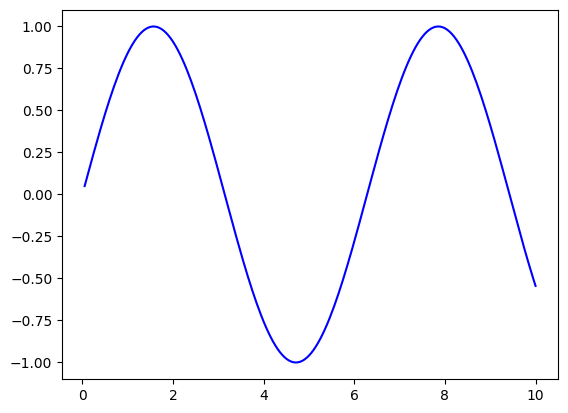

In [2]:
import matplotlib.pyplot as plt


# Example 1: forward Laplace of f(t)=sin(t)  =>  F(s)=1/(s^2+1)
f_fn = lambda t: jnp.sin(t)
s = jnp.array([0.5, 1.0, 2.0], dtype=jnp.float64)

F1 = forward_laplace_change_of_vars(f_fn, s, L=2.0, N=2000)
print("forward (change-of-vars):", F1)            # compare to 1/(s^2+1)

# Example 2: inverse with Durbin (complex F)
F_fn_cplx = lambda s: 1.0 / (s**2 + 1.0)          # Laplace{sin t}
t = jnp.linspace(0.05, 10.0, 200)
f_durbin = inverse_laplace_durbin(F_fn_cplx, t, gamma=0.5, n_freq=1024)
# should look like sin(t)

plt.plot(t, f_durbin, label='Durbin inverse', color='blue')